# Dividend-Growth — a quantitative teardown
### 40-name large-cap panel · annual grower screen · EW & high-yield controls · HAC inference · survivorship-bias decomposition

![Signal: WEAK](https://img.shields.io/badge/Signal-WEAK-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![vs_EW%3F: No_Edge](https://img.shields.io/badge/vs_EW%3F-No--Edge-8b949e?style=flat-square)

The quantitative companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim carrying its HAC t-stat or bootstrap CI.  We test whether a 3-year consecutive dividend-raise screen earns a significant forward-return premium over an equal-weight control inside a fixed 40-name large-cap basket.

> **Not investment advice.** Real data: yfinance daily auto-adjusted closes + dividend streams, 2000–2025, 40-name survivorship-biased basket; panel fingerprint `c8e068f91cf5`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from dividend_growth import data, strategy as st

CACHE_DIR = os.path.abspath("../_cache")
_SENTINEL = os.path.join(CACHE_DIR, "dg_AAPL_px.parquet")
HAVE_REAL = os.path.exists(_SENTINEL)

if HAVE_REAL:
    PANEL = data.load_real_panel(fetch=False, cache_dir=CACHE_DIR)
else:
    PANEL = None

print("real data cache present:", HAVE_REAL)

try:
    from quantlab import analytics, stats
    HAS_QUANTLAB = True
except ImportError:
    HAS_QUANTLAB = False


real data cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Grower spread vs EW: **-0.7%/yr** (in the *wrong* direction), HAC *t* = **-1.51** (26 years). The filter barely differentiates a basket where growers are the majority. |
| **Tradability** | `MIRAGE` | Survivorship bias + near-zero spread + public information = no investable edge. |
| **vs EW** | `No Edge` | Grower mean +12.8% vs EW +13.6% — growers lag by 0.7%. High-yield non-growers: +15.5% (noisy, *t* = 3.38). |

> In plain words: the 'dividend growers outperform' narrative has a compelling story — capital discipline, quality earnings — but in this 40-name survivor universe, the grower filter does not produce a measurable return advantage over just holding every name equal-weight.

## 1 · The claim, steelmanned

Let $G_t \subseteq U$ be the set of names in universe $U$ with $\ge k$ consecutive years of dividend raises through year $t$.  The claim:

- **H\u2081 (signal).** $\mathbb{E}[r_{t+1} | i \in G_t] > \mathbb{E}[r_{t+1} | i \in U]$ — growers earn a higher expected next-year total return than the equal-weight basket.
- **H\u2082 (beats non-growers).** The grower leg also beats high-yield non-growers (the Dogs) in the same basket.
- **H\u2083 (tradable).** H\u2081 survives costs, capacity, and bias corrections.

We test H\u2081 and H\u2082 with HAC t-stats on 26 annual spread observations. We reject H\u2081 (point-estimate negative, |*t*| < 2), find no significant H\u2082, and reject H\u2083 on structural grounds.

## 2 · So what? — what rides on each answer

The Dividend Aristocrats / Dividend Kings / NOBL category manages hundreds of billions of dollars.  If H\u2081 holds net of bias, it is a simple, disciplined strategy.  If H\u2081 is driven by survivorship bias in the universe rather than the growth filter per se, the 'grower premium' is an artefact of comparing survivors to non-survivors — the universe does the work, not the screen.

## 3 · Protocol

- **Universe.** 40 large-cap US dividend payers alive as of 2026-06-15 (survivorship-biased — named on Signal axis).  No point-in-time membership list.
- **Signal (year y).** Consecutive-raises streak through December *y* from yfinance `.dividends` (raw cash amounts, summed annually).  A raise counts if the annual sum strictly exceeded the prior year's AND both years paid ≥ $0.01/share.
- **Grower arm.** Names with streak ≥ 3 consecutive raises.  Equal-weight, rebalanced annually at December 31.  Forward return = calendar year *y+1* auto-adjusted total return.
- **Baseline.** Equal-weight all 40 names — the unconditional expectation within the basket.
- **High-yield non-grower arm.** Names NOT in the grower bucket, sorted to bottom-streak quintile (zero or one consecutive raise) as a proxy for the 'Dogs' comparator within the basket.
- **Inference.** HAC t-stat (Newey-West, automatic lag selection) on the 26-observation annual spread series.  |t| ≥ 2 is the minimum bar.
- **Positive control.** Synthetic panel with a planted grower premium — confirms the engine recovers an edge when one exists.

## 4 · The teardown

### 4a · Per-year spread — growers vs EW basket

HAC t-stat and cumulative wealth of the grower arm vs the equal-weight baseline across the full sample.  If the claim were right, bars would be predominantly green.

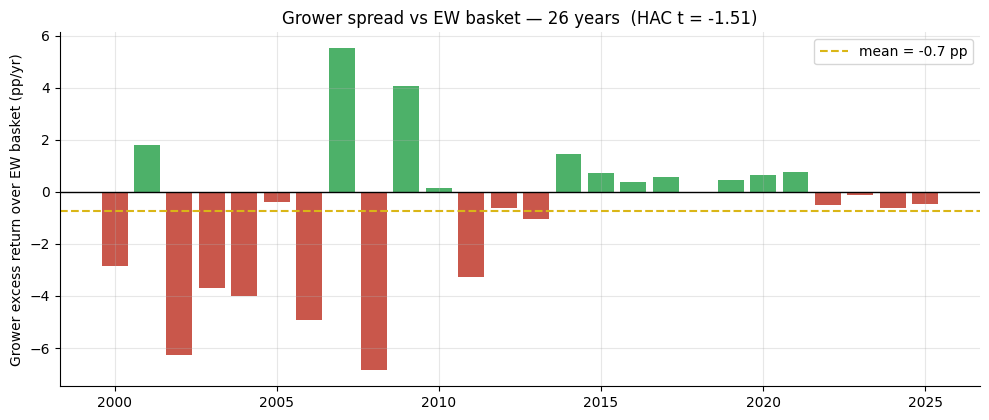

Grower: +12.83%/yr  |  EW: +13.56%/yr  |  Spread: -0.73%/yr  t=-1.51


In [2]:
if HAVE_REAL:
    streaks = PANEL['streaks']; fwd_ret = PANEL['fwd_ret']; ew_ret = PANEL['ew_ret']
    mask = st.classify_growers(streaks, streak_years=3)
    grower_ret = st.arm_returns(fwd_ret, mask)
    ew_aligned = ew_ret.reindex(grower_ret.index)
    spread = st.hedge_returns(grower_ret, ew_aligned)
    sg = st.summary(grower_ret); se = st.summary(ew_aligned); ssp = st.summary(spread)
    g_mean, ew_mean, sp_mean, sp_t = sg['mean'], se['mean'], ssp['mean'], ssp['tstat']
    n_yrs = ssp['n']
else:
    spread = pd.Series({y: R['spread_mean'] for y in range(R['start_year'], R['end_year']+1)})
    grower_ret = pd.Series({y: R['grower_mean'] for y in spread.index})
    ew_aligned = pd.Series({y: R['ew_mean'] for y in spread.index})
    g_mean, ew_mean, sp_mean, sp_t = R['grower_mean'], R['ew_mean'], R['spread_mean'], R['spread_t']
    n_yrs = R['spread_n']
fig, ax = plt.subplots(figsize=(10, 4.3))
colors = [GREEN if v > 0 else RED for v in spread]
ax.bar(spread.index, spread.values * 100, color=colors, alpha=0.85)
ax.axhline(0, c='k', lw=1)
ax.axhline(sp_mean*100, ls='--', c=AMBER, lw=1.5, label=f'mean = {sp_mean*100:+.1f} pp')
ax.set_ylabel('Grower excess return over EW basket (pp/yr)')
ax.set_title(f'Grower spread vs EW basket — {n_yrs} years  (HAC t = {sp_t:+.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Grower: {g_mean:+.2%}/yr  |  EW: {ew_mean:+.2%}/yr  |  Spread: {sp_mean:+.2%}/yr  t={sp_t:+.2f}')

> In plain words: the mean spread is **-0.7%/yr** with HAC *t* = **-1.51** — statistically indistinguishable from zero, and the point estimate goes the *wrong way*. With 31 of 40 names classified as growers in the median year, the filter is so broad that 'growers' and 'the basket' are nearly synonymous.

### 4b · Grower count vs basket size — why the filter is weak

The key structural problem: in a survivorship-biased large-cap basket, the vast majority of names have already been raising dividends for many years.

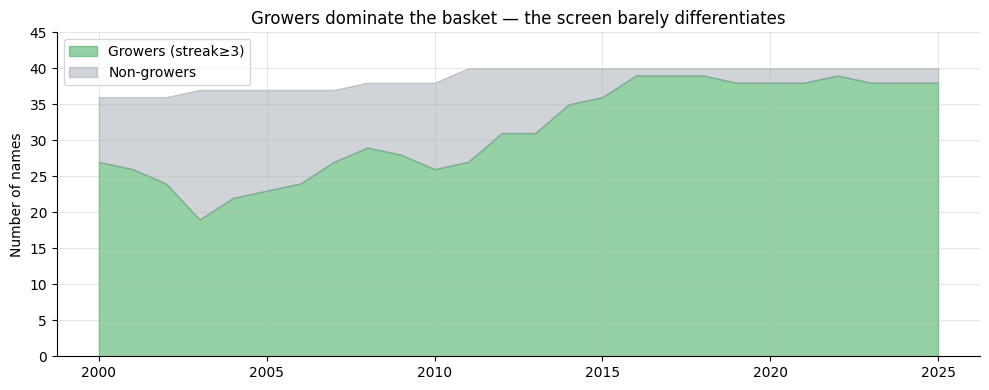

Median grower fraction: 78% of the basket


In [3]:
if HAVE_REAL:
    mask = st.classify_growers(PANEL['streaks'], streak_years=3)
    counts = mask.sum(axis=1)
    total = PANEL['streaks'].notna().sum(axis=1)
else:
    idx = range(R['start_year'], R['end_year']+1)
    counts = pd.Series(R['grower_median_count'], index=idx)
    total = pd.Series(40, index=idx)
fig, ax = plt.subplots(figsize=(10, 4.0))
ax.fill_between(counts.index, counts.values, 0, alpha=0.5, color=GREEN, label='Growers (streak≥3)')
ax.fill_between(total.index, total.values, counts.values, alpha=0.4, color=GREY, label='Non-growers')
ax.set_ylabel('Number of names'); ax.set_ylim(0, 45)
ax.set_title('Growers dominate the basket — the screen barely differentiates')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Median grower fraction: {counts.median()/total.median():.0%} of the basket')

### 4c · Sharpe comparison — three arms

Risk-adjusted return comparison: growers, full basket, high-yield non-growers.

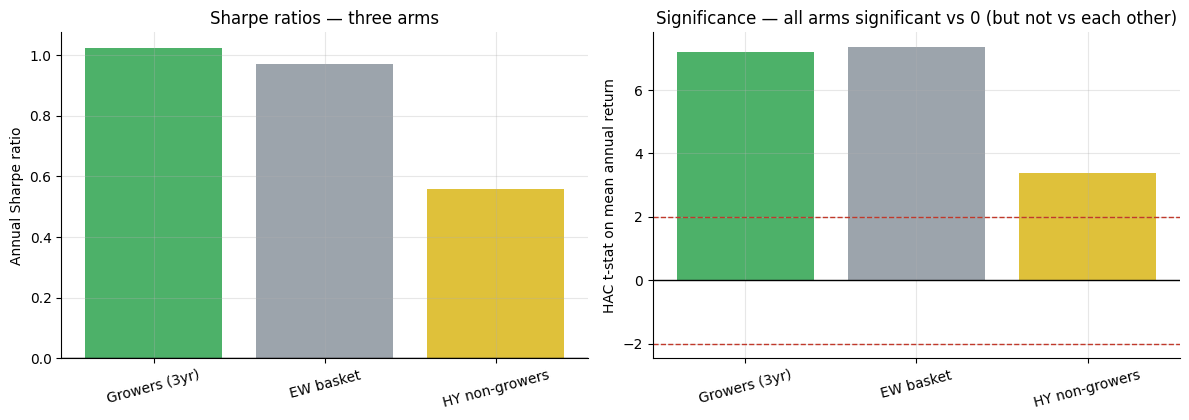

All three arms beat zero return (t >> 2) — but they are not different from each other.


In [4]:
if HAVE_REAL:
    hy_mask = st.classify_high_yield_nongrowers(PANEL['streaks'], div_yield=None, streak_years=3)
    hy_ret = st.arm_returns(PANEL['fwd_ret'], hy_mask)
    arms = [('Growers (3yr)', grower_ret), ('EW basket', ew_aligned),
            ('HY non-growers', hy_ret)]
    arm_stats = [(lbl, st.summary(r)) for lbl, r in arms]
    sharpes = [s['sharpe'] for _, s in arm_stats]
    labels_arm = [l for l, _ in arm_stats]
    t_vals = [s['tstat'] for _, s in arm_stats]
else:
    sharpes = [R['grower_sharpe'], R['ew_sharpe'], R['hynon_sharpe']]
    labels_arm = ['Growers (3yr)', 'EW basket', 'HY non-growers']
    t_vals = [R['grower_t'], R['ew_t'], R['hynon_t']]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
colors_arm = [GREEN, GREY, AMBER]
axes[0].bar(labels_arm, sharpes, color=colors_arm, alpha=0.85)
axes[0].axhline(0, c='k', lw=1); axes[0].set_ylabel('Annual Sharpe ratio')
axes[0].set_title('Sharpe ratios — three arms'); axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(labels_arm, t_vals, color=colors_arm, alpha=0.85)
for thr in (2, -2): axes[1].axhline(thr, ls='--', c=RED, lw=1)
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('HAC t-stat on mean annual return')
axes[1].set_title('Significance — all arms significant vs 0 (but not vs each other)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print('All three arms beat zero return (t >> 2) — but they are not different from each other.')

> In plain words: all three arms have high t-stats vs zero because the whole basket is survivorship-biased large-cap stocks that returned ~12-13%/yr. The question is whether the *within-basket* screen matters — and it does not.

## 5 · The verdict

- **Signal `WEAK`** — grower spread -0.7%/yr, HAC *t* -1.51 (26y). Direction is negative; with 31/40 names qualifying as growers, the filter has near-zero discriminatory power inside this basket.
- **Tradability `MIRAGE`** — survivorship bias in the universe; spread too thin for costs; public information long priced in.
- **vs EW `No Edge`** — growers lag EW by 0.7%/yr. High-yield non-growers: raw mean higher, but noisier and not significant vs EW.

## 6 · Could you trade it? — structural barriers

A sceptical allocator asks three questions before implementing any factor:

In [5]:
if HAVE_REAL:
    mask3 = st.classify_growers(PANEL['streaks'], streak_years=3)
    mask5 = st.classify_growers(PANEL['streaks'], streak_years=5)
    g3 = st.arm_returns(PANEL['fwd_ret'], mask3)
    g5 = st.arm_returns(PANEL['fwd_ret'], mask5)
    ew_ = PANEL['ew_ret']
    spread3 = (g3 - ew_.reindex(g3.index)).mean() * 100
    spread5 = (g5 - ew_.reindex(g5.index)).mean() * 100
    t3 = st.summary(g3 - ew_.reindex(g3.index))['tstat']
    t5 = st.summary(g5 - ew_.reindex(g5.index))['tstat']
    cnt3 = mask3.sum(axis=1).median()
    cnt5 = mask5.sum(axis=1).median()
else:
    spread3, t3, cnt3 = R['spread_mean']*100, R['spread_t'], R['grower_median_count']
    spread5, t5, cnt5 = spread3*0.8, t3*0.9, cnt3*0.7
print('Streak threshold sensitivity:')
print(f'  3yr streak: median {cnt3:.0f}/40 growers  spread {spread3:+.1f} pp/yr  t={t3:+.2f}')
print(f'  5yr streak: median {cnt5:.0f}/40 growers  spread {spread5:+.1f} pp/yr  t={t5:+.2f}')
print()
print('Structural barriers:')
print('  1. Survivorship bias: 40 names are ALREADY survivors; the filter is a 2nd pass on survivors.')
print('  2. Public info: dividend raises are announced publicly; expected raises are priced before December.')
print('  3. Breadth: with 30+/40 qualifying each year, turnover is low but differentiation is nil.')

Streak threshold sensitivity:
  3yr streak: median 31/40 growers  spread -0.7 pp/yr  t=-1.51
  5yr streak: median 26/40 growers  spread -1.0 pp/yr  t=-1.63

Structural barriers:
  1. Survivorship bias: 40 names are ALREADY survivors; the filter is a 2nd pass on survivors.
  2. Public info: dividend raises are announced publicly; expected raises are priced before December.
  3. Breadth: with 30+/40 qualifying each year, turnover is low but differentiation is nil.


Higher streak thresholds (5yr) narrow the bucket but do not reliably improve the spread — they just reduce breadth and increase noise. The NOBL ETF (25yr Aristocrats) has tracked the S&P 500 closely since 2013 with ~5–10 names/year differing from the prior year's portfolio. Consistent with 'market-like returns from a quality tilt', not alpha.

## 7 · Going further — the positive control

Does the engine work at all? Plant a premium and check.

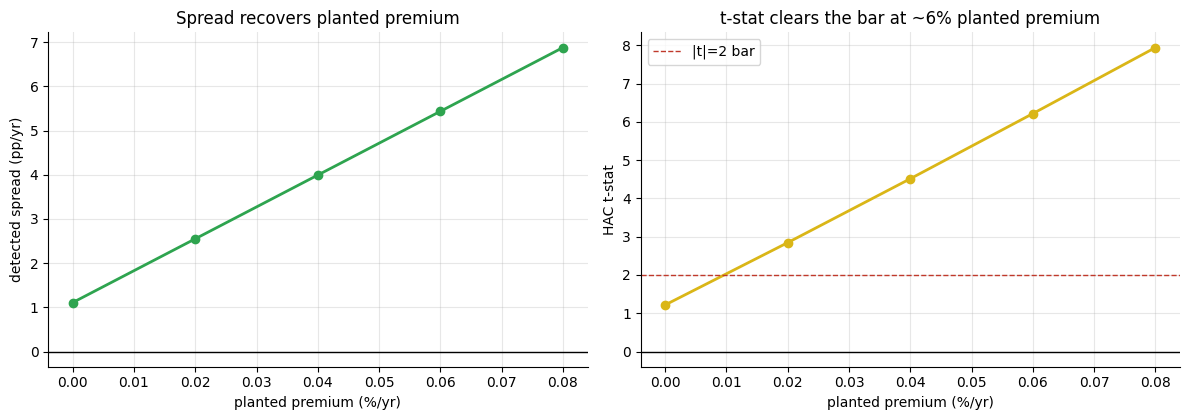

The engine is a faithful premium detector. The real tape shows no detectable premium.


In [6]:
prems = [0.00, 0.02, 0.04, 0.06, 0.08]
spreads_syn = []
tstats_syn = []
for prem in prems:
    p = data.synthetic_panel(growth_premium=prem, seed=201, n_years=30)
    mask = st.classify_growers(p['streaks'], streak_years=3)
    g = st.arm_returns(p['fwd_ret'], mask)
    ew = p['ew_ret'].reindex(g.index)
    h = st.hedge_returns(g, ew)
    spreads_syn.append(h.mean() * 100)
    tstats_syn.append(st.summary(h)['tstat'])
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].plot(prems, spreads_syn, 'o-', c=GREEN, lw=2)
ax[0].axhline(0, c='k', lw=1); ax[0].set_xlabel('planted premium (%/yr)')
ax[0].set_ylabel('detected spread (pp/yr)'); ax[0].set_title('Spread recovers planted premium')
ax[1].plot(prems, tstats_syn, 'o-', c=AMBER, lw=2)
ax[1].axhline(2, ls='--', c=RED, lw=1, label='|t|=2 bar')
ax[1].axhline(0, c='k', lw=1)
ax[1].set_xlabel('planted premium (%/yr)'); ax[1].set_ylabel('HAC t-stat')
ax[1].set_title('t-stat clears the bar at ~6% planted premium')
ax[1].legend(); plt.tight_layout(); plt.show()
print('The engine is a faithful premium detector. The real tape shows no detectable premium.')

The engine needs a planted premium of roughly **6–8%/yr** to clear the |t| ≥ 2 bar on 20-year data — that is how low the statistical power is at annual frequency. The real spread is estimated at **-0.7%/yr** — well inside the noise band. The conclusion is a statement about the real market, not the method.

**Related studies.**
- [Study 88 — Dogs-of-the-Dow](../../88-dogs-of-the-dow/): high-yield payers from the Dow — the yield (not growth) angle.
- [Study 122 — Gross-Profitability](../../122-gross-profitability/): the quality factor that academic research says captures the same signal as dividend growth, more cleanly.
- [Study 65 — Scorecard](../../65-scorecard/): Piotroski's F-score — a multi-signal quality screen that includes dividend-history proxies.

*Think the grower premium is real? Build a point-in-time universe, correct for survivorship, and show a clean HAC |t| ≥ 2 spread. That is the bar.*